### Initial Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### Load data

In [18]:
df = pd.read_csv("../data/games_march2025_cleaned.csv")
df.shape

(89618, 47)

### Structure Overview

In [19]:
df.dtypes.value_counts()

str        23
int64      19
bool        3
float64     2
Name: count, dtype: int64

### Missing Variables

In [20]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})

,n_missing,pct_missing
score_rank,89579,99.96
metacritic_url,86071,96.04
reviews,79217,88.39
notes,72975,81.43
website,48504,54.12
support_url,45508,50.78
support_email,10820,12.07
about_the_game,220,0.25
detailed_description,197,0.22
short_description,120,0.13


### Drop Irrelevant Columns

In [21]:
drop_cols = ["header_image", "website", "support_url", "support_email","metacritic_url", "screenshots", "movies", "packages",
    "detailed_description", "about_the_game", "short_description","notes", "user_score", "score_rank",]

df_eda = df.drop(columns=drop_cols)
df_eda.shape

(89618, 33)

### Parse Genre & Tag Columns into Lists

In [22]:
import ast

list_cols = ["genres", "categories", "developers", "publishers", "supported_languages", "full_audio_languages", "tags"]

def parse_list_col(x):
    try:
        return ast.literal_eval(x) if pd.notna(x) else []
    except (ValueError, SyntaxError):
        return []

for col in list_cols:
    df_eda[col] = df_eda[col].apply(parse_list_col)

df_eda["n_genres"] = df_eda["genres"].apply(len)

### Scoping Analysis

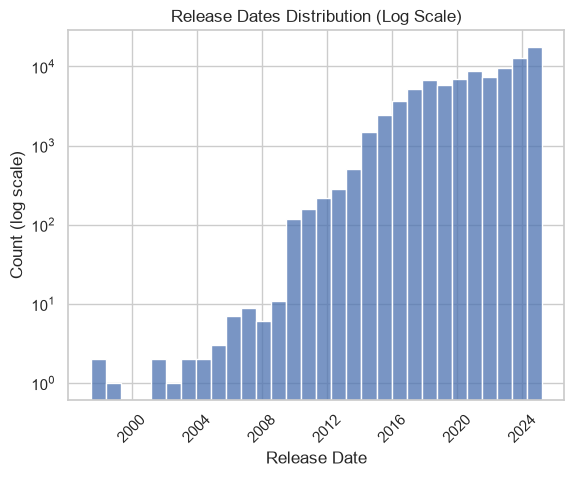

In [23]:
df_eda["release_date"] = pd.to_datetime(df_eda["release_date"], errors="coerce")

sns.histplot(df_eda["release_date"].dropna(), bins=30)
plt.yscale("log")
plt.title("Release Dates Distribution (Log Scale)")
plt.xlabel("Release Date")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=45)

plt.savefig("../assets/rakei-assets/figure1.svg", format="svg", bbox_inches="tight")
plt.show()

### Filtering

In [24]:
df_eda["num_reviews_total"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

count    8.961800e+04
mean     1.315490e+03
std      3.542370e+04
min     -1.000000e+00
10%     -1.000000e+00
25%     -1.000000e+00
50%      1.500000e+01
75%      8.100000e+01
90%      5.100000e+02
max      8.632939e+06
Name: num_reviews_total, dtype: float64

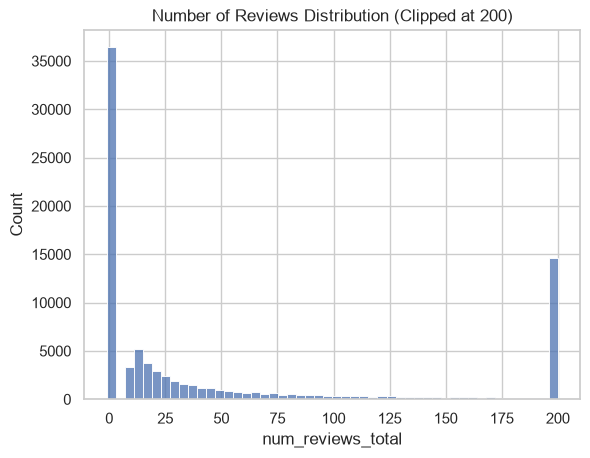

In [25]:
sns.histplot(df_eda["num_reviews_total"].clip(upper=200), bins=50)
plt.title("Number of Reviews Distribution (Clipped at 200)")

plt.savefig("../assets/rakei-assets/figure2.svg", format="svg", bbox_inches="tight")
plt.show()

**Choosing MIN_REVIEWS = 30**

- Steam marks "fewer than 10 reviews" as num_reviews_total == -1 - affects 41% of games
- pct_pos_total is also -1 for those rows (not NaN), so they must be filtered, not imputed
- At n = 10, one review swings pct_pos_total by ~10 points — too noisy to use
- MIN_REVIEWS = 30 cuts that swing to ~3 points per review while keeping a large sample
- 30 is a deliberate margin above Steam's own floor, not an arbitrary round number

In [26]:
MIN_REVIEWS = 30
df_reviewed = df_eda[df_eda["num_reviews_total"] >= MIN_REVIEWS].copy()
print(f"Games kept: {len(df_reviewed)} / {len(df_eda)} ({len(df_reviewed)/len(df_eda)*100:.1f}%)")

Games kept: 34583 / 89618 (38.6%)


### Explode Genres

**Cleaning genres before exploding**

- 109 games in df_reviewed have an empty genre list — dropped, not labeled "Unknown"
  - can't compare a genre against itself if it has no data
  - "Unknown" would just sit at the bottom of every ranking with no analytical value
- Steam mixes non-genre descriptors into the same field — also dropped:
  - Violent, Gore, Nudity, Sexual Content — content ratings, not genres
  - Free To Play, Early Access — business model / release stage, not genre
- Left in without excluding these, they'd distort the top-15 genre rankings

In [27]:
NON_GENRE_DESCRIPTORS = {"Violent", "Gore", "Nudity", "Sexual Content", "Free To Play", "Early Access"}
MIN_GAMES_PER_GENRE = 100

n_zero_genre = (df_reviewed["genres"].apply(len) == 0).sum()
print(f"Games with zero genres in df_reviewed: {n_zero_genre}")

df_reviewed_g = df_reviewed[df_reviewed["genres"].apply(len) > 0].copy()

df_genre = df_reviewed_g.explode("genres").rename(columns={"genres": "genre"})
df_genre = df_genre[df_genre["genre"].notna() & (df_genre["genre"] != "")]

n_unique_before = df_genre["genre"].nunique()
df_genre = df_genre[~df_genre["genre"].isin(NON_GENRE_DESCRIPTORS)]
n_unique_after = df_genre["genre"].nunique()

print(f"Unique genre labels before removing descriptors: {n_unique_before}")
print(f"Unique genre labels after removing descriptors:  {n_unique_after}")
df_genre["genre"].nunique()

Games with zero genres in df_reviewed: 109
Unique genre labels before removing descriptors: 27
Unique genre labels after removing descriptors:  21


21

### Genre Distribution

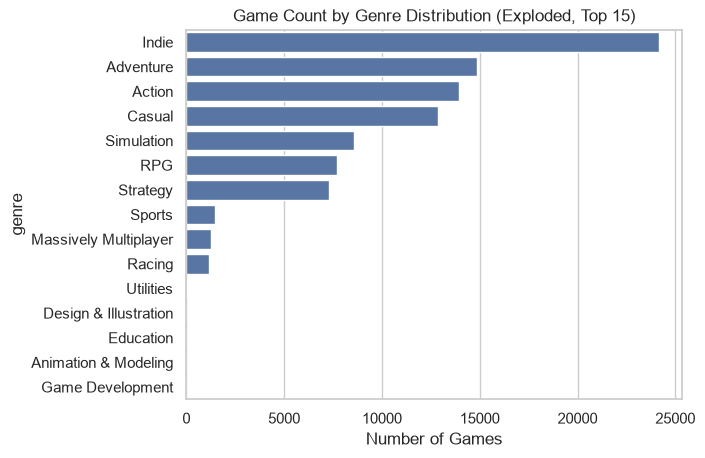

In [28]:
top_genres = df_genre["genre"].value_counts().head(15)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Game Count by Genre Distribution (Exploded, Top 15)")
plt.xlabel("Number of Games")

plt.savefig("../assets/rakei-assets/figure3.svg", format="svg", bbox_inches="tight")
plt.show()

###  Positive Reviews Distribution

**Choosing MIN_GAMES_PER_GENRE = 100**

- Steam's genres field also carries software-tool tags (Accounting, Video Production, etc.)
- These have n = 1–6 games each — a single game can hit 100% or 0% median trivially
- Without a floor, these tiny-sample tags dominate the top of the ranking, ahead of Action/RPG/Indie
- 100 clears out every software-tag genre while keeping all genuine game genres (smallest is Racing at 1,143)

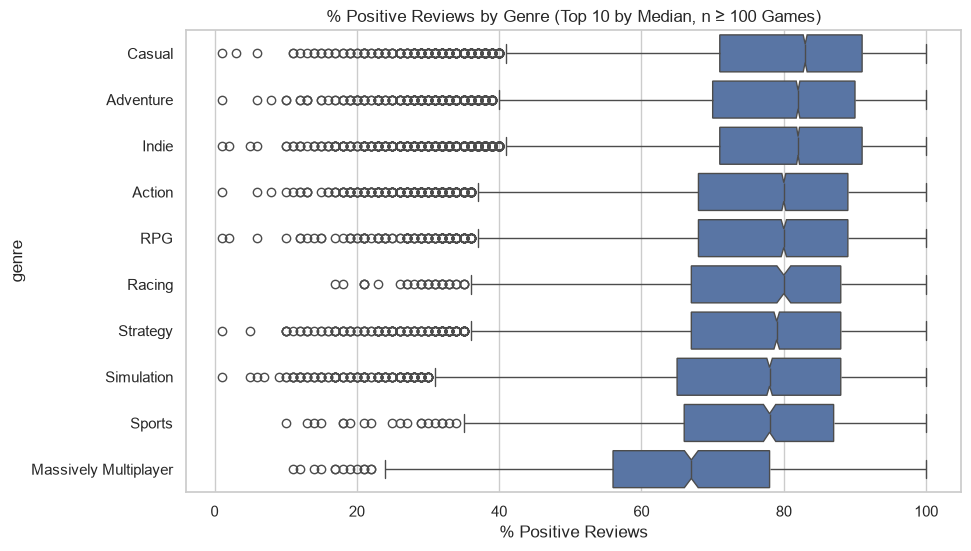

In [33]:
genre_counts = df_genre["genre"].value_counts()
eligible_genres = genre_counts[genre_counts >= MIN_GAMES_PER_GENRE].index

genre_order = (df_genre[df_genre["genre"].isin(eligible_genres)].groupby("genre")["pct_pos_total"].median().sort_values(ascending=False))
top10 = genre_order.head(10).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_genre[df_genre["genre"].isin(top10)],x="pct_pos_total", y="genre", order=top10, notch=True)
plt.title("% Positive Reviews by Genre (Top 10 by Median, n ≥ 100 Games)")
plt.xlabel("% Positive Reviews")

plt.savefig("../assets/rakei-assets/figure4.svg", format="svg", bbox_inches="tight")
plt.show()

### Confounders (Price and Age by Genre)

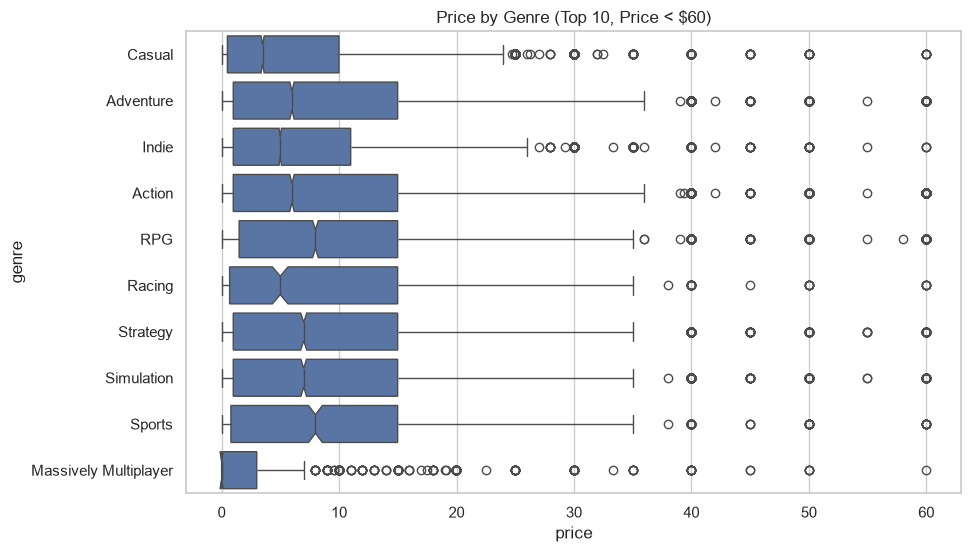

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_genre[df_genre["genre"].isin(top10) & (df_genre["price"] < 60)], x="price", y="genre", order=top10, notch=True)
plt.title("Price by Genre (Top 10, Price < $60)")

plt.savefig("../assets/rakei-assets/figure5.svg", format="svg", bbox_inches="tight")
plt.show()

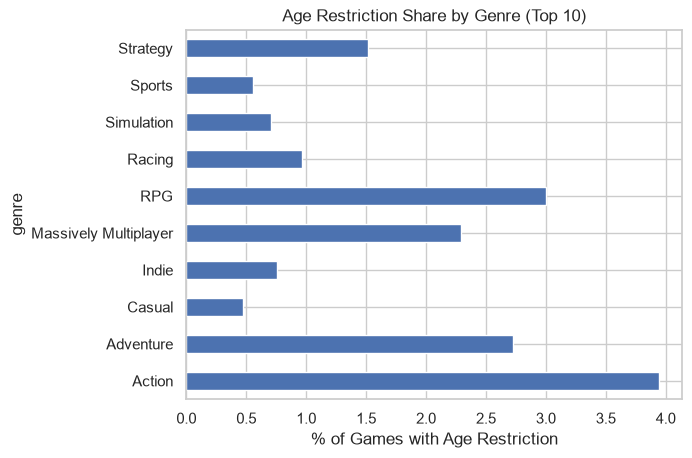

In [31]:
age_by_genre = df_genre[df_genre["genre"].isin(top10)].groupby("genre")["required_age"].apply(lambda x: (x > 0).mean() * 100)
age_by_genre.sort_values(ascending=False).round(1).map(lambda x: f"{x:.1f}%")

age_by_genre.plot(kind="barh")
plt.xlabel("% of Games with Age Restriction")
plt.title("Age Restriction Share by Genre (Top 10)")

plt.savefig("../assets/rakei-assets/figure6.svg", format="svg", bbox_inches="tight")
plt.show()


### Target Missing Variables

In [ ]:
cols_of_interest = ["genres", "pct_pos_total", "price", "required_age", "num_reviews_total"]
df_eda[cols_of_interest].isna().sum() 

genres               0
pct_pos_total        0
price                0
required_age         0
num_reviews_total    0
dtype: int64